In [20]:
###############################
### Kalman calibration code ###
###############################

# Import all the 
import serial
import serial.tools.list_ports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import csv
from datetime import datetime
import os
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [21]:
# List available serial ports
def list_serial_ports():
    """List all available serial ports"""
    ports = serial.tools.list_ports.comports()
    available_ports = []
    
    print("Available serial ports [index : name]:")
    for i, port in enumerate(ports):
        print(f"{i}: {port.device} - {port.description}")
        available_ports.append(port.device)
    
    return available_ports

# List available ports
available_ports = list_serial_ports()

Available serial ports [index : name]:
0: /dev/ttyS4 - n/a
1: /dev/ttyS31 - n/a
2: /dev/ttyS30 - n/a
3: /dev/ttyS29 - n/a
4: /dev/ttyS28 - n/a
5: /dev/ttyS27 - n/a
6: /dev/ttyS26 - n/a
7: /dev/ttyS25 - n/a
8: /dev/ttyS24 - n/a
9: /dev/ttyS23 - n/a
10: /dev/ttyS22 - n/a
11: /dev/ttyS21 - n/a
12: /dev/ttyS20 - n/a
13: /dev/ttyS19 - n/a
14: /dev/ttyS18 - n/a
15: /dev/ttyS17 - n/a
16: /dev/ttyS16 - n/a
17: /dev/ttyS15 - n/a
18: /dev/ttyS14 - n/a
19: /dev/ttyS13 - n/a
20: /dev/ttyS12 - n/a
21: /dev/ttyS11 - n/a
22: /dev/ttyS10 - n/a
23: /dev/ttyS9 - n/a
24: /dev/ttyS8 - n/a
25: /dev/ttyS7 - n/a
26: /dev/ttyS6 - n/a
27: /dev/ttyS5 - n/a
28: /dev/ttyS3 - n/a
29: /dev/ttyS2 - n/a
30: /dev/ttyS1 - n/a
31: /dev/ttyS0 - n/a
32: /dev/ttyUSB0 - FT232R USB UART - FT232R USB UART


In [22]:
# Configuration parameters
PORT_INDEX = 32      # Match port index from above
BAUD_RATE = 9600    # Serial baud
TIMEOUT = 1         # Serial timeout in seconds

# Data collection parameters
DURATION = 60*60  # Data collection duration [sec]
OUTPUT_FILE = f"data/collected_data_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

# Select port
if available_ports:
    PORT = available_ports[PORT_INDEX]
    print(f"Selected port: {PORT}")
else:
    print("No serial ports found!")
    PORT = None

Selected port: /dev/ttyUSB0


In [23]:
# Data Collection Function
def collect_imu_data(port, baudrate, duration, output_file):
    """
    Collect accelerometer and gyroscope data from serial port
    Format expected:
    "Accel X = X.XXX , Y = Y.XXX, Z = Z.XXX"
    "Gyro X = X.XXX , Y = Y.XXX, Z = Z.XXX"
    """
    data = []
    start_time = time.time()
    
    # Initialize data structure
    current_sample = {
        'timestamp': None,
        'accel_x': None,
        'accel_y': None,
        'accel_z': None,
        'gyro_x': None,
        'gyro_y': None,
        'gyro_z': None
    }
    
    try:
        # Open serial port
        ser = serial.Serial(port, baudrate, timeout=TIMEOUT)
        print(f"Connected to {port} at {baudrate} baud")
        print(f"Collecting data for {duration} seconds...")
        
        # Clear buffer
        time.sleep(2)
        ser.reset_input_buffer()
        
        # Collect data
        samples_collected = 0
        while time.time() - start_time < duration:
            try:
                # Read line from serial
                line = ser.readline().decode('utf-8').strip()
                
                if line:
                    # Parse accelerometer data
                    if 'Accel X =' in line:
                        parts = line.split(',')
                        x_part = parts[0].split('=')[1].strip()
                        y_part = parts[1].split('=')[1].strip()
                        z_part = parts[2].split('=')[1].strip()
                        
                        try:
                            current_sample['timestamp'] = time.time() - start_time
                            current_sample['accel_x'] = float(x_part)
                            current_sample['accel_y'] = float(y_part)
                            current_sample['accel_z'] = float(z_part)
                        except ValueError:
                            pass
                    
                    # Parse gyroscope data
                    elif 'Gyro X =' in line:
                        parts = line.split(',')
                        x_part = parts[0].split('=')[1].strip()
                        y_part = parts[1].split('=')[1].strip()
                        z_part = parts[2].split('=')[1].strip()
                        
                        try:
                            current_sample['gyro_x'] = float(x_part)
                            current_sample['gyro_y'] = float(y_part)
                            current_sample['gyro_z'] = float(z_part)
                            
                            # Only save when we have both accel and gyro data
                            if (current_sample['timestamp'] is not None and
                                current_sample['accel_x'] is not None and
                                current_sample['gyro_x'] is not None):
                                
                                data.append(current_sample.copy())
                                samples_collected += 1
                                
                                # Print progress every 50 samples
                                if samples_collected % 50 == 0:
                                    print(f"Collected {samples_collected} samples...")
                                    
                                # Reset current sample
                                current_sample = {
                                    'timestamp': None,
                                    'accel_x': None,
                                    'accel_y': None,
                                    'accel_z': None,
                                    'gyro_x': None,
                                    'gyro_y': None,
                                    'gyro_z': None
                                }
                        except ValueError:
                            pass
                            
            except UnicodeDecodeError:
                continue
            except KeyboardInterrupt:
                print("\nData collection interrupted by user")
                break
                
        print(f"\nCollection complete! Total samples: {len(data)}")
        
        # Save to CSV
        if data:
            df = pd.DataFrame(data)
            df.to_csv(output_file, index=False)
            print(f"Data saved to {output_file}")
        else:
            print("No data collected!")
            return None
            
    except serial.SerialException as e:
        print(f"Error opening serial port: {e}")
        return None
    except Exception as e:
        print(f"Unexpected error: {e}")
        return None
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print("Serial port closed")
    
    return data

In [24]:
# Run data collection
if PORT:
    raw_data = collect_imu_data(PORT, BAUD_RATE, DURATION, OUTPUT_FILE)
else:
    print("No valid port selected. Please check your connection.")
    raw_data = None

Connected to /dev/ttyUSB0 at 9600 baud
Collected 50 samples...
Collected 100 samples...
Collected 150 samples...
Collected 200 samples...
Collected 250 samples...
Collected 300 samples...
Collected 350 samples...
Collected 400 samples...
Collected 450 samples...
Collected 500 samples...
Collected 550 samples...
Collected 600 samples...
Collected 650 samples...
Collected 700 samples...
Collected 750 samples...
Collected 800 samples...
Collected 850 samples...
Collected 900 samples...
Collected 950 samples...
Collected 1000 samples...
Collected 1050 samples...
Collected 1100 samples...
Collected 1150 samples...
Collected 1200 samples...
Collected 1250 samples...
Collected 1300 samples...
Collected 1350 samples...
Collected 1400 samples...
Collected 1450 samples...
Collected 1500 samples...
Collected 1550 samples...
Collected 1600 samples...
Collected 1650 samples...
Collected 1700 samples...
Collected 1750 samples...
Collected 1800 samples...
Collected 1850 samples...
Collected 1900 samp

In [25]:
# Load and Explore Data
if raw_data:
    df = pd.DataFrame(raw_data)
else:
    # Try to load from existing file if collection failed
    try:
        df = pd.read_csv(OUTPUT_FILE)
        print(f"Loaded data from {OUTPUT_FILE}")
    except:
        print("No data available. Please run data collection first.")
        df = None

if df is not None:
    # Display first few rows
    print("First 5 rows of data:")
    display(df.head())
    
    # Basic information about the dataset
    print("\nDataset info:")
    print(f"Number of samples: {len(df)}")
    print(f"Time span: {df['timestamp'].max():.2f} seconds")
    print(f"Sampling rate: {len(df)/df['timestamp'].max():.1f} Hz")
    
    # Check for missing values
    print(f"\nMissing values:\n{df.isnull().sum()}")


First 5 rows of data:


,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,2.051238,-1.007,-0.024,0.019,-4.260,-1.298,0.824
1,2.146649,-1.005,-0.021,0.012,-4.359,-1.313,0.863
2,2.226375,-1.014,-0.023,0.017,-4.313,-1.252,0.779
3,2.321722,-1.003,-0.024,0.021,-4.206,-1.305,0.916
4,2.417244,-1.011,-0.021,0.015,-4.076,-1.244,0.916



Dataset info:
Number of samples: 39486
Time span: 3599.95 seconds
Sampling rate: 11.0 Hz

Missing values:
timestamp    0
accel_x      0
accel_y      0
accel_z      0
gyro_x       0
gyro_y       0
gyro_z       0
dtype: int64


In [26]:
# Statistical Analysis
if df is not None:
    # Calculate statistics for accelerometer
    print("\n" + "="*60)
    print("ACCELEROMETER STATISTICS")
    print("="*60)
    
    accel_stats = pd.DataFrame({
        'Axis': ['X', 'Y', 'Z'],
        'Mean (g)': [df['accel_x'].mean(), df['accel_y'].mean(), df['accel_z'].mean()],
        'Std Dev (g)': [df['accel_x'].std(), df['accel_y'].std(), df['accel_z'].std()],
        'Min (g)': [df['accel_x'].min(), df['accel_y'].min(), df['accel_z'].min()],
        'Max (g)': [df['accel_x'].max(), df['accel_y'].max(), df['accel_z'].max()],
        'RMS (g)': [np.sqrt(np.mean(df['accel_x']**2)), 
                    np.sqrt(np.mean(df['accel_y']**2)),
                    np.sqrt(np.mean(df['accel_z']**2))]
    })
    
    display(accel_stats.round(4))
    
    # Calculate statistics for gyroscope
    print("\n" + "="*60)
    print("GYROSCOPE STATISTICS")
    print("="*60)
    
    gyro_stats = pd.DataFrame({
        'Axis': ['X', 'Y', 'Z'],
        'Mean (°/s)': [df['gyro_x'].mean(), df['gyro_y'].mean(), df['gyro_z'].mean()],
        'Std Dev (°/s)': [df['gyro_x'].std(), df['gyro_y'].std(), df['gyro_z'].std()],
        'Min (°/s)': [df['gyro_x'].min(), df['gyro_y'].min(), df['gyro_z'].min()],
        'Max (°/s)': [df['gyro_x'].max(), df['gyro_y'].max(), df['gyro_z'].max()],
        'RMS (°/s)': [np.sqrt(np.mean(df['gyro_x']**2)), 
                      np.sqrt(np.mean(df['gyro_y']**2)),
                      np.sqrt(np.mean(df['gyro_z']**2))]
    })
    
    display(gyro_stats.round(4))
    
    # Calculate magnitude of acceleration vector
    df['accel_magnitude'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
    
    print(f"\nAcceleration magnitude statistics:")
    print(f"  Mean magnitude: {df['accel_magnitude'].mean():.4f} g")
    print(f"  Std magnitude: {df['accel_magnitude'].std():.4f} g")
    
    # Calculate magnitude of gyro vector
    df['gyro_magnitude'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    
    print(f"\nGyroscope magnitude statistics:")
    print(f"  Mean magnitude: {df['gyro_magnitude'].mean():.4f} °/s")
    print(f"  Std magnitude: {df['gyro_magnitude'].std():.4f} °/s")



ACCELEROMETER STATISTICS


,Axis,Mean (g),Std Dev (g),Min (g),Max (g),RMS (g)
0,X,-1.0075,0.0032,-1.020,-0.995,1.0075
1,Y,-0.0205,0.0026,-0.031,-0.010,0.0207
2,Z,0.0183,0.0040,0.003,0.036,0.0187



GYROSCOPE STATISTICS


,Axis,Mean (°/s),Std Dev (°/s),Min (°/s),Max (°/s),RMS (°/s)
0,X,-4.2328,0.0638,-4.504,-3.992,4.2333
1,Y,-1.2725,0.0923,-1.901,-0.710,1.2759
2,Z,0.8518,0.0712,0.519,1.168,0.8547



Acceleration magnitude statistics:
  Mean magnitude: 1.0079 g
  Std magnitude: 0.0032 g

Gyroscope magnitude statistics:
  Mean magnitude: 4.5028 °/s
  Std magnitude: 0.0668 °/s


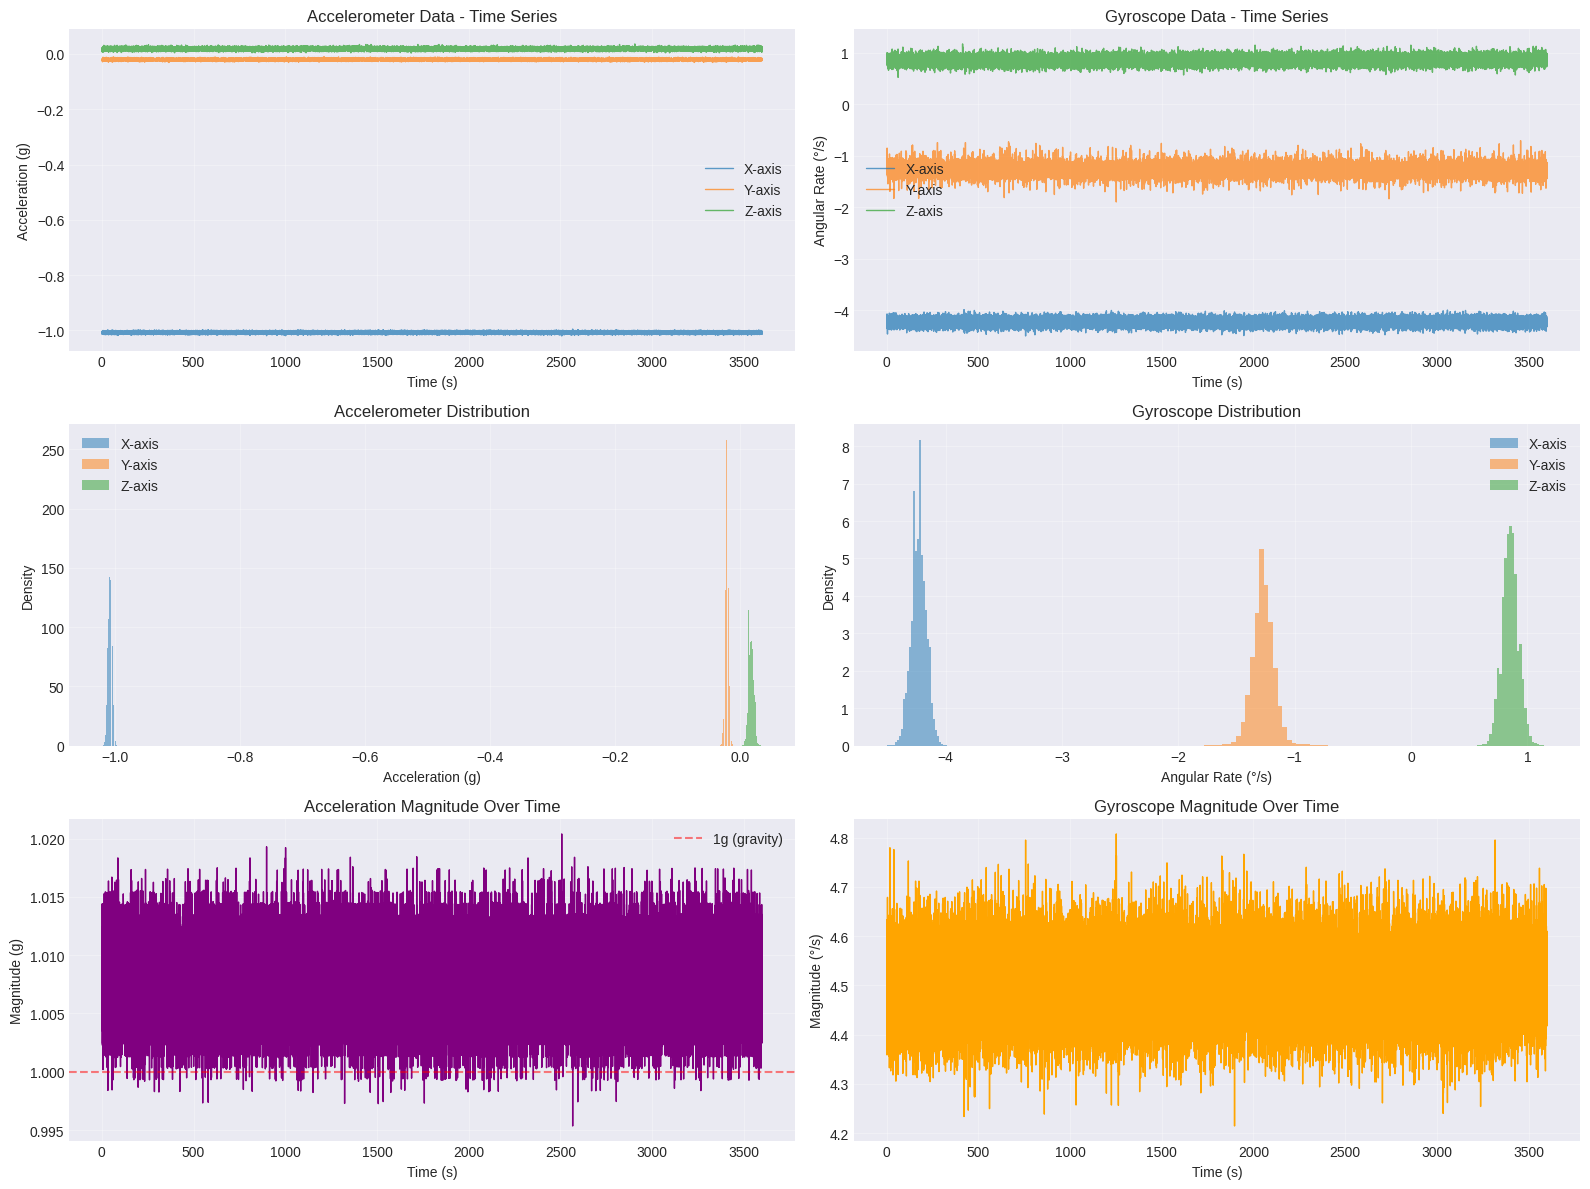

In [27]:
# Data Visualization
if df is not None:
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # Plot 1: Time series of accelerometer axes
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(df['timestamp'], df['accel_x'], label='X-axis', linewidth=1, alpha=0.7)
    ax1.plot(df['timestamp'], df['accel_y'], label='Y-axis', linewidth=1, alpha=0.7)
    ax1.plot(df['timestamp'], df['accel_z'], label='Z-axis', linewidth=1, alpha=0.7)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Acceleration (g)')
    ax1.set_title('Accelerometer Data - Time Series')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Time series of gyroscope axes
    ax2 = plt.subplot(3, 2, 2)
    ax2.plot(df['timestamp'], df['gyro_x'], label='X-axis', linewidth=1, alpha=0.7)
    ax2.plot(df['timestamp'], df['gyro_y'], label='Y-axis', linewidth=1, alpha=0.7)
    ax2.plot(df['timestamp'], df['gyro_z'], label='Z-axis', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Angular Rate (°/s)')
    ax2.set_title('Gyroscope Data - Time Series')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Histograms of accelerometer axes
    ax3 = plt.subplot(3, 2, 3)
    ax3.hist(df['accel_x'], bins=30, alpha=0.5, label='X-axis', density=True)
    ax3.hist(df['accel_y'], bins=30, alpha=0.5, label='Y-axis', density=True)
    ax3.hist(df['accel_z'], bins=30, alpha=0.5, label='Z-axis', density=True)
    ax3.set_xlabel('Acceleration (g)')
    ax3.set_ylabel('Density')
    ax3.set_title('Accelerometer Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Histograms of gyroscope axes
    ax4 = plt.subplot(3, 2, 4)
    ax4.hist(df['gyro_x'], bins=30, alpha=0.5, label='X-axis', density=True)
    ax4.hist(df['gyro_y'], bins=30, alpha=0.5, label='Y-axis', density=True)
    ax4.hist(df['gyro_z'], bins=30, alpha=0.5, label='Z-axis', density=True)
    ax4.set_xlabel('Angular Rate (°/s)')
    ax4.set_ylabel('Density')
    ax4.set_title('Gyroscope Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Acceleration magnitude
    ax5 = plt.subplot(3, 2, 5)
    ax5.plot(df['timestamp'], df['accel_magnitude'], color='purple', linewidth=1)
    ax5.set_xlabel('Time (s)')
    ax5.set_ylabel('Magnitude (g)')
    ax5.set_title('Acceleration Magnitude Over Time')
    ax5.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='1g (gravity)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Gyroscope magnitude
    ax6 = plt.subplot(3, 2, 6)
    ax6.plot(df['timestamp'], df['gyro_magnitude'], color='orange', linewidth=1)
    ax6.set_xlabel('Time (s)')
    ax6.set_ylabel('Magnitude (°/s)')
    ax6.set_title('Gyroscope Magnitude Over Time')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [28]:
# TEST: Interactive Data Visualization with Plotly - Accelerometer & Gyroscope

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import os
from IPython.display import HTML, display

# Create html directory if it doesn't exist
os.makedirs('html', exist_ok=True)

if df is not None:
    # Calculate magnitudes if not already done
    if 'accel_magnitude' not in df.columns:
        df['accel_magnitude'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
    if 'gyro_magnitude' not in df.columns:
        df['gyro_magnitude'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    
    # Create a subplot figure with 3x2 grid for both sensors
    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=('Accelerometer - Time Series', 
                       'Gyroscope - Time Series',
                       'Accelerometer - Distribution',
                       'Gyroscope - Distribution',
                       'Accelerometer - Magnitude',
                       'Gyroscope - Magnitude'),
        specs=[[{}, {}],
               [{'type': 'xy'}, {'type': 'xy'}],
               [{'type': 'xy'}, {'type': 'xy'}]]
    )
    
    # ============================================
    # Plot 1: Accelerometer time series (row 1, col 1)
    # ============================================
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_x'], 
                  mode='lines', name='Accel X', line=dict(width=1, color='red')),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_y'], 
                  mode='lines', name='Accel Y', line=dict(width=1, color='green')),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_z'], 
                  mode='lines', name='Accel Z', line=dict(width=1, color='blue')),
        row=1, col=1
    )
    
    # ============================================
    # Plot 2: Gyroscope time series (row 1, col 2)
    # ============================================
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['gyro_x'], 
                  mode='lines', name='Gyro X', line=dict(width=1, color='darkred')),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['gyro_y'], 
                  mode='lines', name='Gyro Y', line=dict(width=1, color='darkgreen')),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['gyro_z'], 
                  mode='lines', name='Gyro Z', line=dict(width=1, color='darkblue')),
        row=1, col=2
    )
    
    # ============================================
    # Plot 3: Accelerometer histograms (row 2, col 1)
    # ============================================
    fig.add_trace(
        go.Histogram(x=df['accel_x'], name='Accel X', opacity=0.5,
                    histnorm='probability density', nbinsx=30, 
                    marker_color='red', showlegend=False),
        row=2, col=1
    )
    fig.add_trace(
        go.Histogram(x=df['accel_y'], name='Accel Y', opacity=0.5,
                    histnorm='probability density', nbinsx=30,
                    marker_color='green', showlegend=False),
        row=2, col=1
    )
    fig.add_trace(
        go.Histogram(x=df['accel_z'], name='Accel Z', opacity=0.5,
                    histnorm='probability density', nbinsx=30,
                    marker_color='blue', showlegend=False),
        row=2, col=1
    )
    
    # ============================================
    # Plot 4: Gyroscope histograms (row 2, col 2)
    # ============================================
    fig.add_trace(
        go.Histogram(x=df['gyro_x'], name='Gyro X', opacity=0.5,
                    histnorm='probability density', nbinsx=30,
                    marker_color='darkred', showlegend=False),
        row=2, col=2
    )
    fig.add_trace(
        go.Histogram(x=df['gyro_y'], name='Gyro Y', opacity=0.5,
                    histnorm='probability density', nbinsx=30,
                    marker_color='darkgreen', showlegend=False),
        row=2, col=2
    )
    fig.add_trace(
        go.Histogram(x=df['gyro_z'], name='Gyro Z', opacity=0.5,
                    histnorm='probability density', nbinsx=30,
                    marker_color='darkblue', showlegend=False),
        row=2, col=2
    )
    
    # ============================================
    # Plot 5: Accelerometer magnitude (row 3, col 1)
    # ============================================
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_magnitude'], 
                  mode='lines', name='Accel Magnitude', 
                  line=dict(color='purple', width=1)),
        row=3, col=1
    )
    
    # Add horizontal line for 1g (gravity)
    fig.add_hline(y=1.0, line_dash="dash", line_color="red", 
                  annotation_text="1g (gravity)", row=3, col=1)
    
    # ============================================
    # Plot 6: Gyroscope magnitude (row 3, col 2)
    # ============================================
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['gyro_magnitude'], 
                  mode='lines', name='Gyro Magnitude', 
                  line=dict(color='orange', width=1)),
        row=3, col=2
    )
    
    # Add horizontal line at zero for reference
    fig.add_hline(y=0, line_dash="dot", line_color="gray", 
                  annotation_text="Zero", row=3, col=2)
    
    # Update layout
    fig.update_layout(
        height=1200,
        showlegend=True,
        title_text="IMU Data Analysis - Accelerometer & Gyroscope (Interactive Plot)",
        hovermode='x unified',
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.05
        )
    )
    
    # Update axes labels
    # Row 1
    fig.update_xaxes(title_text="Time (s)", row=1, col=1)
    fig.update_yaxes(title_text="Acceleration (g)", row=1, col=1)
    
    fig.update_xaxes(title_text="Time (s)", row=1, col=2)
    fig.update_yaxes(title_text="Angular Rate (°/s)", row=1, col=2)
    
    # Row 2
    fig.update_xaxes(title_text="Acceleration (g)", row=2, col=1)
    fig.update_yaxes(title_text="Density", row=2, col=1)
    
    fig.update_xaxes(title_text="Angular Rate (°/s)", row=2, col=2)
    fig.update_yaxes(title_text="Density", row=2, col=2)
    
    # Row 3
    fig.update_xaxes(title_text="Time (s)", row=3, col=1)
    fig.update_yaxes(title_text="Magnitude (g)", row=3, col=1)
    
    fig.update_xaxes(title_text="Time (s)", row=3, col=2)
    fig.update_yaxes(title_text="Magnitude (°/s)", row=3, col=2)
    
    # Save to HTML file
    html_file = "html/imu_plot.html"
    fig.write_html(html_file)
    print(f"Plot saved as '{html_file}'")
    
    # Display link
    print("\nClick the link below to open the interactive plot in your browser:")
    display(HTML(f'<a href="{html_file}" target="_blank" style="font-size: 16px; color: blue;">Open {html_file} in new tab</a>'))

# Additional Interactive Plots - 3D Visualization

if df is not None:
    # Create separate 3D plots for better visualization
    
    # ============================================
    # 3D Accelerometer Space
    # ============================================
    # Downsample for 3D plot if dataset is large
    if len(df) > 1000:
        plot_df = df.iloc[::len(df)//1000].copy()
    else:
        plot_df = df.copy()
    
    fig_3d_accel = go.Figure()
    
    fig_3d_accel.add_trace(
        go.Scatter3d(
            x=plot_df['accel_x'], 
            y=plot_df['accel_y'], 
            z=plot_df['accel_z'],
            mode='markers',
            marker=dict(
                size=3,
                color=plot_df['timestamp'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title="Time (s)")
            ),
            text=[f"Time: {t:.2f}s<br>X: {x:.3f}g<br>Y: {y:.3f}g<br>Z: {z:.3f}g" 
                  for t, x, y, z in zip(plot_df['timestamp'], 
                                        plot_df['accel_x'], 
                                        plot_df['accel_y'], 
                                        plot_df['accel_z'])],
            hoverinfo='text',
            name='Accelerometer'
        )
    )
    
    fig_3d_accel.update_layout(
        title='3D Acceleration Space',
        scene=dict(
            xaxis_title='X (g)',
            yaxis_title='Y (g)',
            zaxis_title='Z (g)',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=800,
        height=600
    )
    
    html_file_3d_accel = "html/3d_accelerometer.html"
    fig_3d_accel.write_html(html_file_3d_accel)
    print(f"\n3D Accelerometer plot saved: {html_file_3d_accel}")
    
    # ============================================
    # 3D Gyroscope Space
    # ============================================
    fig_3d_gyro = go.Figure()
    
    fig_3d_gyro.add_trace(
        go.Scatter3d(
            x=plot_df['gyro_x'], 
            y=plot_df['gyro_y'], 
            z=plot_df['gyro_z'],
            mode='markers',
            marker=dict(
                size=3,
                color=plot_df['timestamp'],
                colorscale='Plasma',
                showscale=True,
                colorbar=dict(title="Time (s)")
            ),
            text=[f"Time: {t:.2f}s<br>X: {x:.3f}°/s<br>Y: {y:.3f}°/s<br>Z: {z:.3f}°/s" 
                  for t, x, y, z in zip(plot_df['timestamp'], 
                                        plot_df['gyro_x'], 
                                        plot_df['gyro_y'], 
                                        plot_df['gyro_z'])],
            hoverinfo='text',
            name='Gyroscope'
        )
    )
    
    fig_3d_gyro.update_layout(
        title='3D Gyroscope Space',
        scene=dict(
            xaxis_title='X (°/s)',
            yaxis_title='Y (°/s)',
            zaxis_title='Z (°/s)',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=800,
        height=600
    )
    
    html_file_3d_gyro = "html/3d_gyroscope.html"
    fig_3d_gyro.write_html(html_file_3d_gyro)
    print(f"3D Gyroscope plot saved: {html_file_3d_gyro}")

# Correlation Analysis Between Sensors

if df is not None:
    # Calculate correlation matrix
    corr_matrix = df[['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']].corr()
    
    # Create correlation heatmap
    fig_corr = go.Figure(data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.columns,
        colorscale='RdBu',
        zmid=0,
        text=corr_matrix.round(3).values,
        texttemplate='%{text}',
        textfont={"size": 10},
        hoverongaps=False
    ))
    
    fig_corr.update_layout(
        title='Sensor Correlation Matrix',
        width=600,
        height=600,
        xaxis_title='Sensor Axis',
        yaxis_title='Sensor Axis'
    )
    
    html_file_corr = "html/correlation_matrix.html"
    fig_corr.write_html(html_file_corr)
    print(f"\nCorrelation matrix saved: {html_file_corr}")

# Gyroscope Drift Analysis (Interactive)

if df is not None and len(df) > 100:
    dt = 0.005  # Assuming 200Hz sampling
    fig_drift = make_subplots(
        rows=3, cols=1,
        subplot_titles=('Gyro X - Integrated Angle', 
                       'Gyro Y - Integrated Angle',
                       'Gyro Z - Integrated Angle'),
        shared_xaxes=True,
        vertical_spacing=0.1
    )
    
    for i, axis in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
        # Integrate to get angle
        angle = np.cumsum(df[axis] * dt)
        
        # Fit trend line
        z = np.polyfit(df['timestamp'], angle, 1)
        trend_line = np.poly1d(z)(df['timestamp'])
        drift_rate = z[0]
        
        # Add raw integrated angle
        fig_drift.add_trace(
            go.Scatter(x=df['timestamp'], y=angle,
                      mode='lines', name=f'{axis} integrated',
                      line=dict(width=1)),
            row=i+1, col=1
        )
        
        # Add trend line
        fig_drift.add_trace(
            go.Scatter(x=df['timestamp'], y=trend_line,
                      mode='lines', name=f'Trend ({drift_rate:.6f} °/s)',
                      line=dict(dash='dash', color='red', width=2)),
            row=i+1, col=1
        )
    
    fig_drift.update_layout(
        height=900,
        title_text="Gyroscope Drift Analysis",
        hovermode='x unified',
        showlegend=True
    )
    
    fig_drift.update_xaxes(title_text="Time (s)", row=3, col=1)
    fig_drift.update_yaxes(title_text="Angle (°)", row=1, col=1)
    fig_drift.update_yaxes(title_text="Angle (°)", row=2, col=1)
    fig_drift.update_yaxes(title_text="Angle (°)", row=3, col=1)
    
    html_file_drift = "html/gyro_drift.html"
    fig_drift.write_html(html_file_drift)
    print(f"\nGyroscope drift analysis saved: {html_file_drift}")


# Rolling Statistics (Interactive)

if df is not None:
    window_size = min(50, len(df)//10)
    
    fig_rolling = make_subplots(
        rows=2, cols=3,
        subplot_titles=('Accel X - Rolling Stats', 'Accel Y - Rolling Stats', 'Accel Z - Rolling Stats',
                       'Gyro X - Rolling Stats', 'Gyro Y - Rolling Stats', 'Gyro Z - Rolling Stats'),
        shared_xaxes=True,
        vertical_spacing=0.12,
        horizontal_spacing=0.1
    )
    
    # Define colors in rgba format for fill
    fill_colors = {
        'accel_x': 'rgba(255, 0, 0, 0.2)',      # red with 0.2 opacity
        'accel_y': 'rgba(0, 255, 0, 0.2)',      # green with 0.2 opacity
        'accel_z': 'rgba(0, 0, 255, 0.2)',      # blue with 0.2 opacity
        'gyro_x': 'rgba(139, 0, 0, 0.2)',       # darkred with 0.2 opacity
        'gyro_y': 'rgba(0, 100, 0, 0.2)',       # darkgreen with 0.2 opacity
        'gyro_z': 'rgba(0, 0, 139, 0.2)'        # darkblue with 0.2 opacity
    }
    
    colors = {'accel_x': 'red', 'accel_y': 'green', 'accel_z': 'blue',
              'gyro_x': 'darkred', 'gyro_y': 'darkgreen', 'gyro_z': 'darkblue'}
    
    # Accelerometer rolling stats
    for i, axis in enumerate(['accel_x', 'accel_y', 'accel_z']):
        rolling_mean = df[axis].rolling(window=window_size, center=True).mean()
        rolling_std = df[axis].rolling(window=window_size, center=True).std()
        
        # Raw data
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], y=df[axis],
                      mode='lines', name=f'{axis} raw',
                      line=dict(color=colors[axis], width=0.5),
                      opacity=0.3,
                      showlegend=False),
            row=1, col=i+1
        )
        
        # Rolling mean
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], y=rolling_mean,
                      mode='lines', name=f'{axis} mean',
                      line=dict(color=colors[axis], width=2),
                      showlegend=False),
            row=1, col=i+1
        )
        
        # Confidence band (upper bound) - set to invisible
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], 
                      y=rolling_mean + rolling_std,
                      mode='lines', 
                      line=dict(width=0, color=colors[axis]),
                      showlegend=False,
                      hoverinfo='none'),
            row=1, col=i+1
        )
        
        # Confidence band (lower bound) with fill to upper bound
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], 
                      y=rolling_mean - rolling_std,
                      mode='lines', 
                      fill='tonexty',
                      fillcolor=fill_colors[axis],
                      line=dict(width=0, color=colors[axis]),
                      showlegend=False,
                      hoverinfo='none'),
            row=1, col=i+1
        )
    
    # Gyroscope rolling stats
    for i, axis in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
        rolling_mean = df[axis].rolling(window=window_size, center=True).mean()
        rolling_std = df[axis].rolling(window=window_size, center=True).std()
        
        # Raw data
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], y=df[axis],
                      mode='lines', name=f'{axis} raw',
                      line=dict(color=colors[axis], width=0.5),
                      opacity=0.3,
                      showlegend=False),
            row=2, col=i+1
        )
        
        # Rolling mean
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], y=rolling_mean,
                      mode='lines', name=f'{axis} mean',
                      line=dict(color=colors[axis], width=2),
                      showlegend=False),
            row=2, col=i+1
        )
        
        # Confidence band (upper bound) - set to invisible
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], 
                      y=rolling_mean + rolling_std,
                      mode='lines', 
                      line=dict(width=0, color=colors[axis]),
                      showlegend=False,
                      hoverinfo='none'),
            row=2, col=i+1
        )
        
        # Confidence band (lower bound) with fill to upper bound
        fig_rolling.add_trace(
            go.Scatter(x=df['timestamp'], 
                      y=rolling_mean - rolling_std,
                      mode='lines', 
                      fill='tonexty',
                      fillcolor=fill_colors[axis],
                      line=dict(width=0, color=colors[axis]),
                      showlegend=False,
                      hoverinfo='none'),
            row=2, col=i+1
        )
    
    fig_rolling.update_layout(
        height=800,
        title_text=f"Rolling Statistics (window size = {window_size})",
        hovermode='x unified',
        showlegend=False
    )
    
    fig_rolling.update_xaxes(title_text="Time (s)", row=2, col=2)
    
    html_file_rolling = "html/rolling_stats.html"
    fig_rolling.write_html(html_file_rolling)
    print(f"\nRolling statistics plot saved: {html_file_rolling}")

# Summary of Generated Plots
print("\n" + "="*60)
print("GENERATED INTERACTIVE PLOTS")
print("="*60)
print("\nThe following interactive HTML plots have been created in the 'html' directory:")
print("imu_plot.html          - Main dashboard with 6 subplots")
print("3d_accelerometer.html  - 3D scatter of accelerometer data")
print("3d_gyroscope.html      - 3D scatter of gyroscope data")
print("correlation_matrix.html - Correlation heatmap between all axes")
print("gyro_drift.html        - Gyroscope drift analysis")
print("rolling_stats.html     - Rolling statistics with confidence bands")
print("\nOpen these files in any web browser to interact with the plots!")

Plot saved as 'html/imu_plot.html'

Click the link below to open the interactive plot in your browser:



3D Accelerometer plot saved: html/3d_accelerometer.html
3D Gyroscope plot saved: html/3d_gyroscope.html

Correlation matrix saved: html/correlation_matrix.html

Gyroscope drift analysis saved: html/gyro_drift.html

Rolling statistics plot saved: html/rolling_stats.html

GENERATED INTERACTIVE PLOTS

The following interactive HTML plots have been created in the 'html' directory:
imu_plot.html          - Main dashboard with 6 subplots
3d_accelerometer.html  - 3D scatter of accelerometer data
3d_gyroscope.html      - 3D scatter of gyroscope data
correlation_matrix.html - Correlation heatmap between all axes
gyro_drift.html        - Gyroscope drift analysis
rolling_stats.html     - Rolling statistics with confidence bands

Open these files in any web browser to interact with the plots!


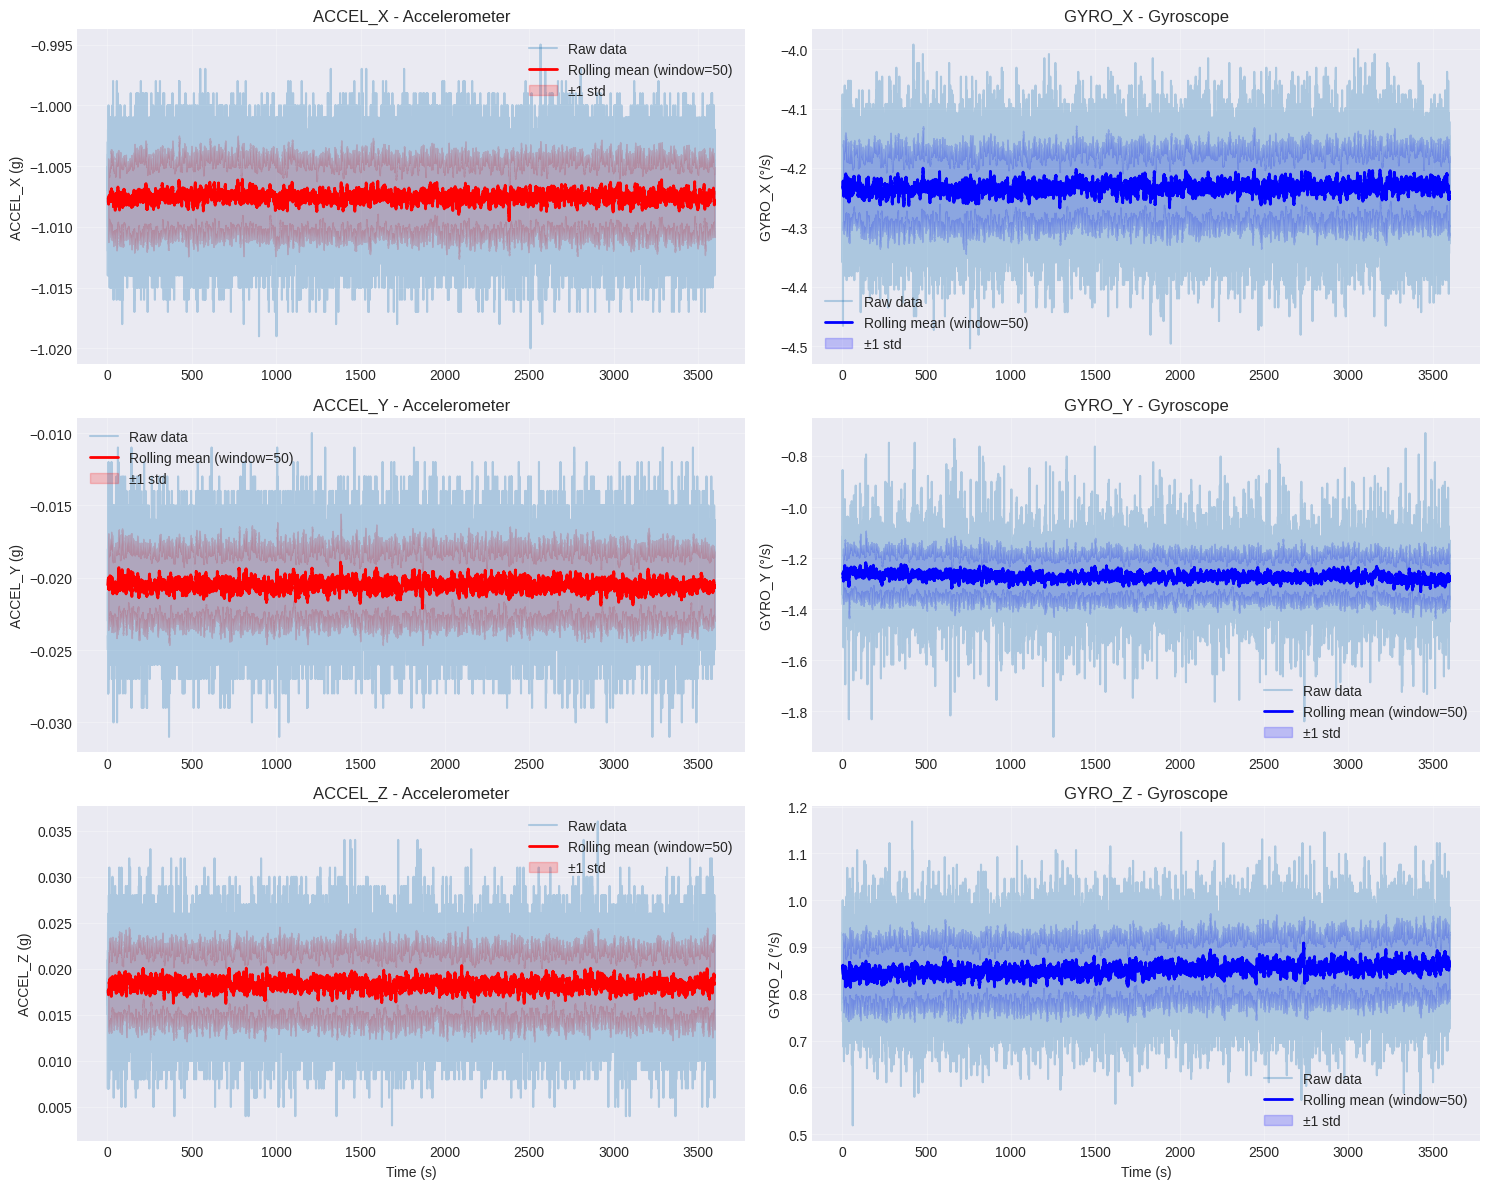

In [29]:
# Advanced Analysis - Rolling Statistics

if df is not None:
    window_size = min(50, len(df)//10)
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    # Accelerometer axes
    for i, axis in enumerate(['accel_x', 'accel_y', 'accel_z']):
        rolling_mean = df[axis].rolling(window=window_size, center=True).mean()
        rolling_std = df[axis].rolling(window=window_size, center=True).std()
        
        axes[i, 0].plot(df['timestamp'], df[axis], alpha=0.3, label='Raw data')
        axes[i, 0].plot(df['timestamp'], rolling_mean, 'r-', linewidth=2, 
                        label=f'Rolling mean (window={window_size})')
        axes[i, 0].fill_between(df['timestamp'], 
                               rolling_mean - rolling_std, 
                               rolling_mean + rolling_std, 
                               alpha=0.2, color='r', label='±1 std')
        axes[i, 0].set_ylabel(f'{axis.upper()} (g)')
        axes[i, 0].set_title(f'{axis.upper()} - Accelerometer')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
    
    # Gyroscope axes
    for i, axis in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
        rolling_mean = df[axis].rolling(window=window_size, center=True).mean()
        rolling_std = df[axis].rolling(window=window_size, center=True).std()
        
        axes[i, 1].plot(df['timestamp'], df[axis], alpha=0.3, label='Raw data')
        axes[i, 1].plot(df['timestamp'], rolling_mean, 'b-', linewidth=2,
                        label=f'Rolling mean (window={window_size})')
        axes[i, 1].fill_between(df['timestamp'],
                               rolling_mean - rolling_std,
                               rolling_mean + rolling_std,
                               alpha=0.2, color='b', label='±1 std')
        axes[i, 1].set_ylabel(f'{axis.upper()} (°/s)')
        axes[i, 1].set_title(f'{axis.upper()} - Gyroscope')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
    
    axes[2, 0].set_xlabel('Time (s)')
    axes[2, 1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

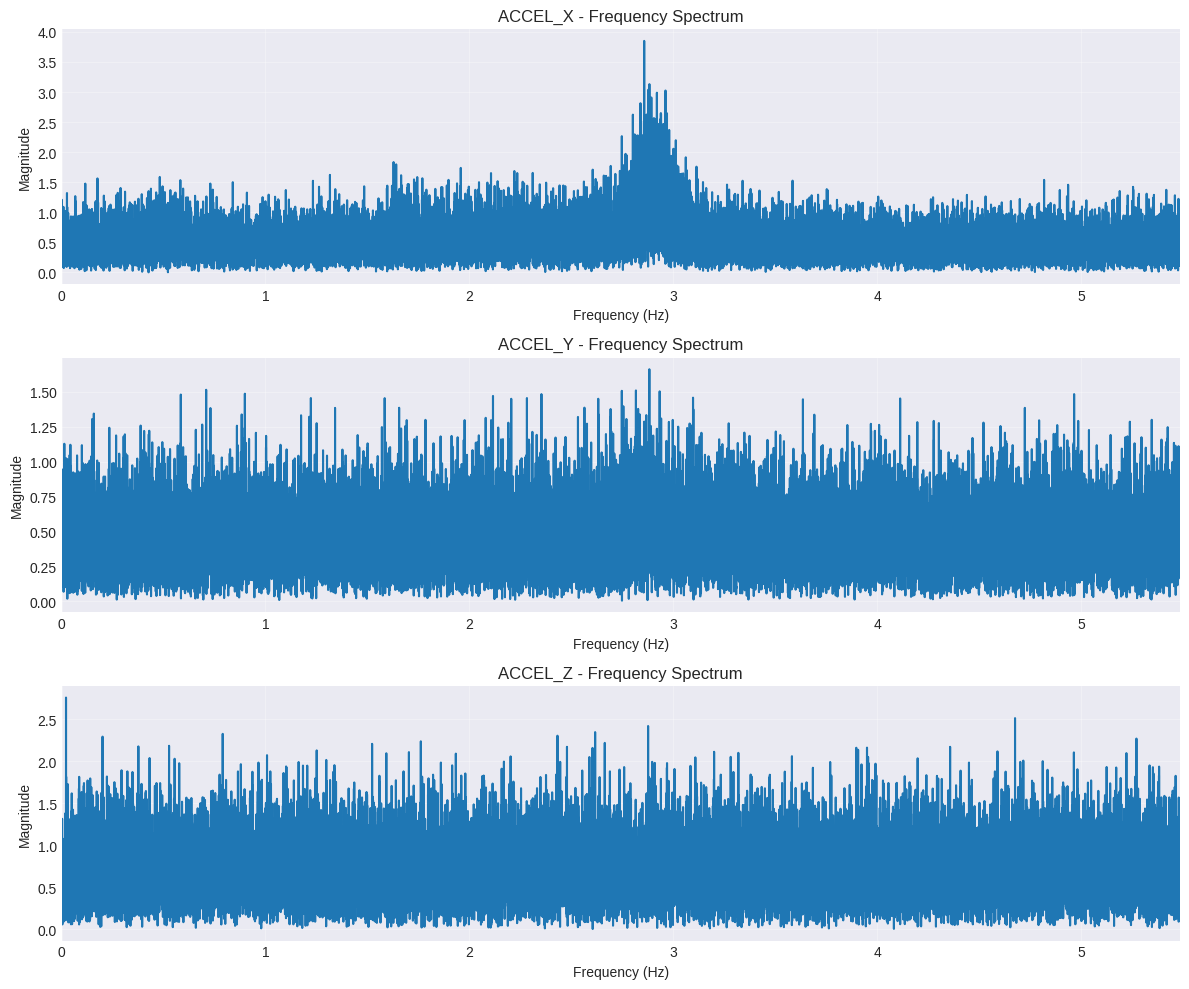

Estimated sampling rate: 11.0 Hz
Nyquist frequency: 5.5 Hz


In [30]:
# FFT Analysis (Frequency Domain)

if df is not None and len(df) > 10:
    from scipy import signal
    
    # Calculate FFT for each axis
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    sampling_rate = len(df) / df['timestamp'].max()
    
    for i, axis in enumerate(['accel_x', 'accel_y', 'accel_z']):
        # Detrend the data
        data_detrended = signal.detrend(df[axis].values)
        
        # Compute FFT
        fft_vals = np.fft.fft(data_detrended)
        fft_freq = np.fft.fftfreq(len(data_detrended), 1/sampling_rate)
        
        # Take positive frequencies only
        pos_mask = fft_freq > 0
        fft_freq = fft_freq[pos_mask]
        fft_mag = np.abs(fft_vals[pos_mask])
        
        # Plot
        axes[i].plot(fft_freq, fft_mag)
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Magnitude')
        axes[i].set_title(f'{axis.upper()} - Frequency Spectrum')
        axes[i].set_xlim([0, sampling_rate/2])  # Nyquist frequency
        axes[i].grid(True, alpha=0.3)
        
        # Optional: log scale for better visualization
        #axes[i].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Estimated sampling rate: {sampling_rate:.1f} Hz")
    print(f"Nyquist frequency: {sampling_rate/2:.1f} Hz")


In [31]:
# Export Results

if df is not None:
    # Create summary report
    summary_stats = pd.DataFrame({
        'Axis': ['X', 'Y', 'Z'],
        'Mean': [df['accel_x'].mean(), df['accel_y'].mean(), df['accel_z'].mean()],
        'Std': [df['accel_x'].std(), df['accel_y'].std(), df['accel_z'].std()],
        'Min': [df['accel_x'].min(), df['accel_y'].min(), df['accel_z'].min()],
        'Max': [df['accel_x'].max(), df['accel_y'].max(), df['accel_z'].max()]
    })
    
    # Save summary to CSV
    OUTPUT_FILE_SUM = f"summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    summary_file = f"summary/{OUTPUT_FILE_SUM}"
    summary_stats.to_csv(summary_file, index=False)
    print(f"Summary statistics saved to {summary_file}")
    
    # Display final summary
    print("\n=== FINAL SUMMARY ===")
    print(f"Data file: {OUTPUT_FILE}")
    print(f"Total samples: {len(df)}")
    print(f"Recording duration: {df['timestamp'].max():.2f} seconds")
    print(f"Average sampling rate: {len(df)/df['timestamp'].max():.1f} Hz")
    print("\nAxis Statistics:")
    display(summary_stats.round(4))




Summary statistics saved to summary/summary_20260301_173029.csv

=== FINAL SUMMARY ===
Data file: data/collected_data_20260301_163019.csv
Total samples: 39486
Recording duration: 3599.95 seconds
Average sampling rate: 11.0 Hz

Axis Statistics:


,Axis,Mean,Std,Min,Max
0,X,-1.0075,0.0032,-1.020,-0.995
1,Y,-0.0205,0.0026,-0.031,-0.010
2,Z,0.0183,0.0040,0.003,0.036



KALMAN FILTER TUNING CALCULATOR (200Hz)
Sampling rate: 200 Hz
Time step (dt): 5.0 ms
Total samples: 39486
Recording duration: 3599.95 seconds
----------------------------------------------------------------------

1. ACCELEROMETER NOISE ANALYSIS
--------------------------------------------------
Accelerometer noise (standard deviation):
  X-axis: 0.003156 g
  Y-axis: 0.002602 g
  Z-axis: 0.004010 g

2. GYROSCOPE NOISE ANALYSIS
--------------------------------------------------
Gyroscope noise (standard deviation):
  X-axis: 0.063803 °/s
  Y-axis: 0.092259 °/s
  Z-axis: 0.071187 °/s

3. GYRO BIAS DRIFT ANALYSIS
--------------------------------------------------

GYRO_X:
  Drift rate: -0.232263 °/s per second
  Drift per step (dt=0.005s): -0.00116131 °
  Q_bias estimate: 0.000001348649

GYRO_Y:
  Drift rate: -0.069853 °/s per second
  Drift per step (dt=0.005s): -0.00034927 °
  Q_bias estimate: 0.000000121988

GYRO_Z:
  Drift rate: 0.046736 °/s per second
  Drift per step (dt=0.005s): 0

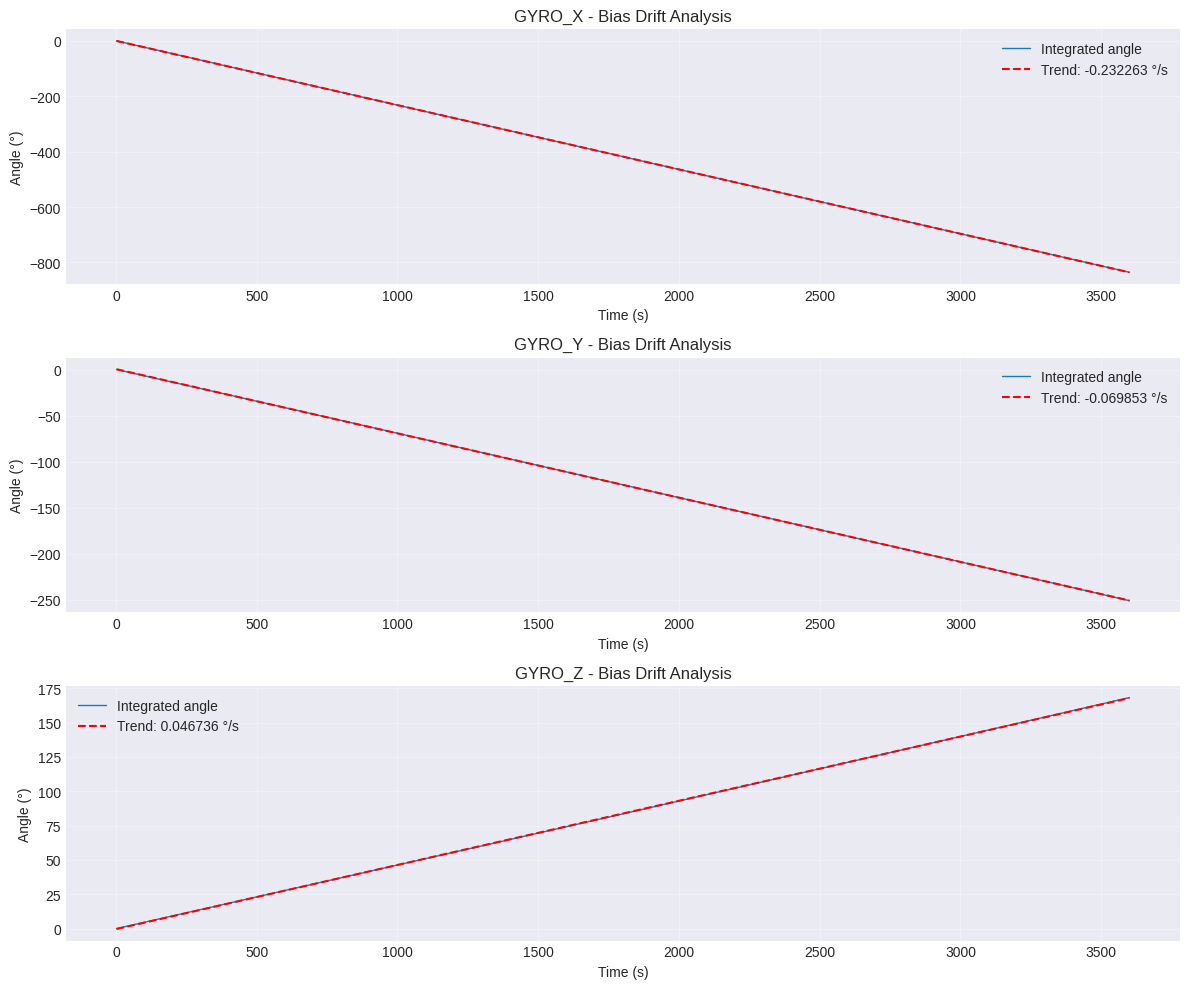

In [32]:
# Kalman Filter Tuning Calculator

def calculate_kalman_params_200hz(df, dt=0.005):  # dt = 1/200Hz
    """
    Calculate optimal Kalman filter parameters based on collected sensor data
    for a 200Hz filter (dt = 0.005s)
    """
    
    print("\n" + "="*70)
    print("KALMAN FILTER TUNING CALCULATOR (200Hz)")
    print("="*70)
    print(f"Sampling rate: {1/dt:.0f} Hz")
    print(f"Time step (dt): {dt*1000:.1f} ms")
    print(f"Total samples: {len(df)}")
    print(f"Recording duration: {df['timestamp'].max():.2f} seconds")
    print("-"*70)
    
    # 1. Calculate accelerometer noise characteristics
    print("\n1. ACCELEROMETER NOISE ANALYSIS")
    print("-"*50)
    
    accel_noise = df[['accel_x', 'accel_y', 'accel_z']].std()
    
    print(f"Accelerometer noise (standard deviation):")
    print(f"  X-axis: {accel_noise['accel_x']:.6f} g")
    print(f"  Y-axis: {accel_noise['accel_y']:.6f} g")
    print(f"  Z-axis: {accel_noise['accel_z']:.6f} g")
    
    # 2. Calculate gyroscope noise characteristics
    print("\n2. GYROSCOPE NOISE ANALYSIS")
    print("-"*50)
    
    gyro_noise = df[['gyro_x', 'gyro_y', 'gyro_z']].std()
    
    print(f"Gyroscope noise (standard deviation):")
    print(f"  X-axis: {gyro_noise['gyro_x']:.6f} °/s")
    print(f"  Y-axis: {gyro_noise['gyro_y']:.6f} °/s")
    print(f"  Z-axis: {gyro_noise['gyro_z']:.6f} °/s")
    
    # 3. Calculate gyro bias drift (if sensor is stationary)
    print("\n3. GYRO BIAS DRIFT ANALYSIS")
    print("-"*50)
    
    # Calculate cumulative integral to estimate drift
    # This assumes the sensor was stationary during recording
    gyro_bias_drift = {}
    for axis in ['gyro_x', 'gyro_y', 'gyro_z']:
        # Integrate gyro to get angle drift
        angle_drift = np.cumsum(df[axis] * dt)
        
        # Fit linear trend to estimate drift rate
        z = np.polyfit(df['timestamp'], angle_drift, 1)
        drift_rate = z[0]  # slope in °/s
        
        # Bias drift per second
        bias_drift_per_sec = drift_rate
        
        # Bias drift per time step
        bias_drift_per_step = bias_drift_per_sec * dt
        
        gyro_bias_drift[axis] = {
            'drift_rate_per_sec': bias_drift_per_sec,
            'drift_rate_per_step': bias_drift_per_step,
            'Q_bias_estimate': (bias_drift_per_step)**2
        }
        
        print(f"\n{axis.upper()}:")
        print(f"  Drift rate: {bias_drift_per_sec:.6f} °/s per second")
        print(f"  Drift per step (dt={dt}s): {bias_drift_per_step:.8f} °")
        print(f"  Q_bias estimate: {bias_drift_per_step**2:.12f}")
    
    # 4. Calculate recommended R_measure (measurement noise)
    print("\n4. R_MEASURE CALCULATION")
    print("-"*50)
    
    # Convert accelerometer noise to angle noise
    # For small angles, angle ≈ acceleration/g (in radians)
    angle_noise_deg = np.rad2deg(np.arctan2(accel_noise, 1.0))
    
    # R_measure should be the variance of the measurement noise
    r_variance = max(accel_noise)**2 * 100  # Conservative estimate (10x)
    r_angle_based = (max(angle_noise_deg))**2
    
    # For 200Hz, typical R_measure range: 0.001 to 0.1
    r_recommended = np.clip(max(r_variance, r_angle_based), 0.001, 0.1)
    
    print(f"Max accelerometer noise: {max(accel_noise):.6f} g")
    print(f"Max angle noise: {max(angle_noise_deg):.6f}°")
    print(f"Variance-based R: {r_variance:.6f}")
    print(f"Angle-based R:    {r_angle_based:.6f}")
    print(f"Recommended R:    {r_recommended:.6f}")
    
    # 5. Calculate recommended Q_angle (process noise for angle)
    print("\n5. Q_ANGLE CALCULATION")
    print("-"*50)
    
    # Based on gyro noise and expected dynamics
    max_gyro_noise = max(gyro_noise)
    max_angle_change_per_step = max_gyro_noise * dt
    
    # Q_angle should be the variance of the angle prediction error
    q_angle_gyro = (max_angle_change_per_step)**2
    
    # For 200Hz, typical Q_angle range: 1e-6 to 1e-4
    q_angle_min = 1e-7
    q_angle_max = 1e-3
    q_angle_recommended = np.clip(q_angle_gyro * 10, q_angle_min, q_angle_max)
    
    print(f"Max gyro noise: {max_gyro_noise:.6f} °/s")
    print(f"Max angle change per step: {max_angle_change_per_step:.8f}°")
    print(f"Gyro-based Q_angle: {q_angle_gyro:.8f}")
    print(f"Recommended Q_angle: {q_angle_recommended:.8f}")
    
    # 6. Calculate recommended Q_bias
    print("\n6. Q_BIAS CALCULATION")
    print("-"*50)
    
    # Use the maximum bias drift estimate
    max_bias_drift = max([v['drift_rate_per_step'] for v in gyro_bias_drift.values()])
    q_bias_calculated = (max_bias_drift)**2
    
    # For 200Hz, typical Q_bias range: 1e-10 to 1e-8
    q_bias_min = 1e-12
    q_bias_max = 1e-7
    q_bias_recommended = np.clip(q_bias_calculated * 10, q_bias_min, q_bias_max)
    
    print(f"Max bias drift per step: {max_bias_drift:.10f}°")
    print(f"Calculated Q_bias: {q_bias_calculated:.12f}")
    print(f"Recommended Q_bias: {q_bias_recommended:.12f}")
    
    # 7. Final Recommendations
    print("\n" + "="*70)
    print("FINAL KALMAN FILTER PARAMETERS (200Hz)")
    print("="*70)
    print(f"""
    // Kalman filter parameters for 200Hz operation (dt = {dt}s)
    const float Q_angle = {q_angle_recommended:.8f}f;   // Process noise - angle
    const float Q_bias  = {q_bias_recommended:.12f}f;   // Process noise - bias drift
    const float R_measure = {r_recommended:.6f}f;       // Measurement noise
    
    // Tuning guidelines:
    // - If filter is too noisy:  Increase R_measure, decrease Q_angle
    // - If filter is too slow:    Decrease R_measure, increase Q_angle
    // - If bias drifts too fast:  Decrease Q_bias
    // - If bias adapts too slow:  Increase Q_bias
    """)
    
    return {
        'Q_angle': q_angle_recommended,
        'Q_bias': q_bias_recommended,
        'R_measure': r_recommended,
        'dt': dt,
        'accel_noise': accel_noise,
        'gyro_noise': gyro_noise,
        'gyro_drift': gyro_bias_drift
    }

# %%
# Run the Kalman tuning calculator
if df is not None:
    kalman_params = calculate_kalman_params_200hz(df, dt=0.005)  # 200Hz
    
    # Plot gyro drift analysis
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    for i, axis in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
        # Integrate to get angle drift
        angle_drift = np.cumsum(df[axis] * 0.005)
        
        # Fit trend line
        z = np.polyfit(df['timestamp'], angle_drift, 1)
        trend = np.poly1d(z)
        
        axes[i].plot(df['timestamp'], angle_drift, label='Integrated angle', linewidth=1)
        axes[i].plot(df['timestamp'], trend(df['timestamp']), 'r--', 
                    label=f'Trend: {z[0]:.6f} °/s')
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Angle (°)')
        axes[i].set_title(f'{axis.upper()} - Bias Drift Analysis')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [33]:
# Clean Up

# Close any remaining plots
plt.close('all')
print("Analysis complete!")

Analysis complete!
